# W2–W3 · Thu thập và kiểm tra chất lượng dữ liệu thời tiết Hà Nội
**Dự án:** dự báo nhiệt độ và mưa trước 1 giờ bằng dữ liệu NASA POWER.  
**Phạm vi hiện tại:** một điểm đại diện Hà Nội (21.0285, 105.8542), dữ liệu theo giờ UTC từ 2023–2024, 7 biến khí tượng. **Phạm vi notebook: raw → kiểm tra chất lượng → xử lý thiếu → cleaned.**

Notebook đi theo slide, mỗi phần có **mục đích → code → cách đọc kết quả**. Chạy bằng **Run All** trong VS Code/Jupyter sau khi đặt vào `Weather-Prediction-ML/notebooks/` hoặc thư mục gốc dự án. Đọc dữ liệu **raw**, không lấy dữ liệu đã nội suy để đánh giá chất lượng ban đầu.

| Phần | Căn cứ tài liệu | Áp dụng vào dự án |
|---|---|---|
| W2: nguồn, định dạng, API | Trang 6–16, 24–28 | NASA POWER, JSON gốc → CSV, metadata và kiểm tra phản hồi |
| W2: sáu kiểm tra ban đầu, raw bất biến | Trang 19–22 | shape, info, head, dtype, missing, duplicate; SHA-256 |
| W2: data dictionary | Trang 37 | Đủ 11 cột raw, đơn vị đọc từ metadata |
| W3: audit, 6 chiều, 3 mức lỗi | Trang 7–11 | Bảng audit, phạm vi thời gian, miền giá trị, khóa, đối chiếu JSON |
| W3: missing ẩn và cơ chế | Trang 13–18 | -999, chuỗi rỗng, NaN, missing theo tháng/giờ |
| W3: chọn cách xử lý | Trang 20–29 | Chính sách từng biến, cờ thiếu, nhật ký; thận trọng với mưa/hướng gió |
| W3: so sánh và báo cáo | Trang 31–35 | n/mean/std, histogram, thử nghiệm riêng và báo cáo xuất file |

**Phân biệt với bài tập nguyên văn:** EX2.1 yêu cầu 500 tin VnExpress, EX2.3 yêu cầu kiểm tra robots.txt và ảnh chụp. Notebook này **chuyển quy trình sang dự án thời tiết theo yêu cầu**, không thay thế bài nộp VnExpress nếu giảng viên vẫn yêu cầu riêng. Không giả lập ảnh chụp hay tuyên bố đã kiểm tra điều khoản nguồn.

In [1]:
# Chạy một lần nếu kernel của venv thiếu thư viện, rồi Restart Kernel.
# %pip install pandas numpy matplotlib pyarrow nbformat ipykernel tzdata

## 1. Cấu hình và bảo vệ dữ liệu gốc
**Luồng thực hiện:** đọc CSV/JSON/metadata trong `data/raw/nasa_power/` → audit raw → nhận diện missing/lỗi miền → xử lý trên bản sao → kiểm tra lại → lưu và đọc lại cleaned → đối chiếu raw–cleaned.

Mỗi lần chạy tạo một thư mục riêng `data/cleaned/w2_w3/<RUN_ID>/`, gồm CSV cleaned, Parquet nếu có, metadata và thư mục `reports/`. Không ghi đè raw hoặc file cleaned khác đã có trong dự án. `raw`, `baseline`, `work` là các DataFrame trong bộ nhớ, không phải các tầng dữ liệu bổ sung. Nếu chưa có raw, dùng lệnh thu thập ở phần 2 trước.

In [2]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, sys, subprocess, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = None  # Có thể sửa: Path(r'C:\Users\ameli\OneDrive\Documents\Weather-Prediction-ML')
REL = Path('data/raw/nasa_power/hanoi_hourly_20230101_20241231.csv')
if PROJECT_ROOT is None:
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / REL).exists() or (p / 'src/data_collection/nasa_power.py').exists()), None)
    if ROOT is None:
        raise FileNotFoundError('Đặt notebook trong dự án hoặc điền PROJECT_ROOT ở trên.')
else:
    ROOT = Path(PROJECT_ROOT).expanduser().resolve()
INPUT = ROOT / REL
META_PATH = INPUT.with_suffix('.metadata.json')
WEATHER_COLS = ['T2M','PRECTOTCORR','RH2M','PS','WS2M','WD2M','ALLSKY_SFC_SW_DWN']
REQUIRED = ['timestamp','city','latitude','longitude', *WEATHER_COLS]
CONTINUOUS = ['T2M','RH2M','PS','WS2M']
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR = ROOT / 'data/cleaned/w2_w3' / RUN_ID
REPORT_DIR = OUTPUT_DIR / 'reports'
for p in [REPORT_DIR, OUTPUT_DIR]: p.mkdir(parents=True, exist_ok=True)
def sha256(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (12,4), 'axes.grid': True, 'grid.alpha': .2})
print('Thư mục dự án:', ROOT)

Thư mục dự án: /workspace/scratch/dde99ae4e0a3/project/Weather-Prediction-ML


## 2. W2 — Chọn nguồn và tái lập việc thu thập
**Vì sao chọn API?** Các trường khí tượng có cấu trúc, kèm thời gian và đơn vị; không cần bóc HTML hoặc dùng SQL. Giai đoạn hiện tại chỉ có **một nguồn API NASA POWER**, không gọi đây là đã tích hợp nhiều nguồn. IBTrACS mới là hướng mở rộng cho bão.

Project đã có `src/data_collection/nasa_power.py`: chia 24 yêu cầu theo tháng, đặt UTC, timeout, retry lỗi tạm thời/429/5xx, kiểm tra schema và cache phản hồi. Đây là chia theo thời gian, **không phải pagination bằng số trang**. Không cần API key theo cấu hình dự án. Dùng `sys.executable` để chạy đúng Python của kernel.

Mặc định đọc snapshot sẵn có, không tải lại. Chỉ đổi `RUN_COLLECTION=True` nếu cần tái tạo dữ liệu. Để tải phiên bản mới, thêm `--refresh` theo README và trỏ INPUT vào snapshot mới; không ghi đè raw cũ.

In [3]:
RUN_COLLECTION = False
command = [sys.executable, '-m', 'src.data_collection.nasa_power',
           '--start', '2023-01-01', '--end', '2024-12-31']
print('Lệnh thu thập:', subprocess.list2cmdline(command))
if RUN_COLLECTION:
    subprocess.run(command, cwd=ROOT, check=True)
if not INPUT.exists() or not META_PATH.exists():
    raise FileNotFoundError('Cần CSV raw và .metadata.json: hãy chạy lệnh thu thập bên trên.')
source_meta = json.loads(META_PATH.read_text(encoding='utf-8-sig'))
SOURCE_HASH = sha256(INPUT)
META_HASH = sha256(META_PATH)
print('Nguồn:', 'NASA POWER Hourly Point API')
print('Thời điểm tạo CSV:', source_meta.get('generated_at', 'Chưa ghi'))
print('UTC:', source_meta.get('time_standard'))
print('Số phản hồi trong metadata:', len(source_meta.get('sources', [])))
print('SHA-256 raw:', SOURCE_HASH)
display(pd.DataFrame(source_meta.get('parameters', {})).T)

Lệnh thu thập: /opt/codex/runtimes/codex-primary-runtime/dependencies/python/bin/python3 -m src.data_collection.nasa_power --start 2023-01-01 --end 2024-12-31
Nguồn: NASA POWER Hourly Point API
Thời điểm tạo CSV: 2026-09-26T09:34:07.465990+00:00
UTC: UTC
Số phản hồi trong metadata: 24
SHA-256 raw: df5b860ce9a488136023318de3116b7d7f9e377232443bb5088300a8fe549ee9


,units,longname
T2M,C,Temperature at 2 Meters
PRECTOTCORR,mm/hour,Precipitation Corrected
RH2M,%,Relative Humidity at 2 Meters
PS,kPa,Surface Pressure
WS2M,m/s,Wind Speed at 2 Meters
WD2M,Degrees,Wind Direction at 2 Meters
ALLSKY_SFC_SW_DWN,Wh/m^2,All Sky Surface Shortwave Downward Irradiance


**Metadata cần hiểu:** `generated_at` là thời điểm project tạo file; khoảng 2023–2024 là thời gian của dữ liệu, hai thứ khác nhau. Người thu thập không có trong metadata thì ghi “chưa ghi”, không tự suy đoán. Dữ liệu dạng lưới tại điểm đại diện không chứng minh chính xác tại từng quận/phường.

**Nguồn và trách nhiệm (W2):** URL truy cập được lưu trong metadata. Tài liệu nguồn tham khảo: [NASA POWER Hourly API](https://power.larc.nasa.gov/docs/services/api/temporal/hourly/). Trước khi phân phối hoặc thu thập bổ sung, kiểm tra điều khoản sử dụng và yêu cầu ghi nguồn. Notebook kiểm tra snapshot cục bộ; không coi việc truy cập được API là bằng chứng đã kiểm tra giấy phép, robots.txt hay độ trễ công bố phục vụ dự báo trực tiếp.

## 3. W2 — Sáu câu hỏi bắt buộc sau khi đọc CSV
Đọc lần đầu với quy tắc NaN mặc định để thấy những gì Pandas nhận ra. CSV dự án dùng dấu phẩy và dấu chấm thập phân. `on_bad_lines='error'` giúp tránh âm thầm bỏ dòng.

In [4]:
raw = pd.read_csv(INPUT, encoding='utf-8-sig', sep=',', decimal='.', on_bad_lines='error')
assert len(raw) > 0, 'CSV rỗng.'
assert set(REQUIRED).issubset(raw.columns), f'Thiếu cột: {set(REQUIRED)-set(raw.columns)}'
print('1. shape:', raw.shape)
print('2. info:'); raw.info()
print('3. head:'); display(raw.head(10))
print('4. dtype:'); display(raw.dtypes.to_frame('dtype'))
print('5. Missing Pandas nhận ra:'); display(raw.isna().sum().to_frame('n_missing'))
print('6. Dòng trùng hoàn toàn:', int(raw.duplicated().sum()))

1. shape: (17544, 11)
2. info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          17544 non-null  object 
 1   city               17544 non-null  object 
 2   latitude           17544 non-null  float64
 3   longitude          17544 non-null  float64
 4   T2M                17544 non-null  float64
 5   PRECTOTCORR        17544 non-null  float64
 6   RH2M               17544 non-null  float64
 7   PS                 17544 non-null  float64
 8   WS2M               17544 non-null  float64
 9   WD2M               17544 non-null  float64
 10  ALLSKY_SFC_SW_DWN  17544 non-null  float64
dtypes: float64(9), object(2)
memory usage: 1.5+ MB
3. head:
4. dtype:
5. Missing Pandas nhận ra:
6. Dòng trùng hoàn toàn: 0


,timestamp,city,latitude,longitude,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN
0,2023-01-01T00:00:00Z,Hanoi,21.0285,105.8542,9.75,0.0,83.01,101.62,2.13,17.8,117.28
1,2023-01-01T01:00:00Z,Hanoi,21.0285,105.8542,12.01,0.0,71.80,101.66,2.76,30.0,298.23
2,2023-01-01T02:00:00Z,Hanoi,21.0285,105.8542,14.32,0.0,64.32,101.66,2.79,40.5,474.75
3,2023-01-01T03:00:00Z,Hanoi,21.0285,105.8542,16.32,0.0,60.20,101.60,2.31,41.5,616.85
4,2023-01-01T04:00:00Z,Hanoi,21.0285,105.8542,17.81,0.0,58.20,101.48,1.95,39.8,649.58
5,2023-01-01T05:00:00Z,Hanoi,21.0285,105.8542,18.75,0.0,57.85,101.35,1.67,41.1,663.17
6,2023-01-01T06:00:00Z,Hanoi,21.0285,105.8542,19.26,0.0,58.20,101.22,1.39,47.9,501.70
7,2023-01-01T07:00:00Z,Hanoi,21.0285,105.8542,19.33,0.0,59.11,101.12,1.15,61.9,369.10
8,2023-01-01T08:00:00Z,Hanoi,21.0285,105.8542,18.94,0.0,60.98,101.08,1.02,82.7,229.48
9,2023-01-01T09:00:00Z,Hanoi,21.0285,105.8542,17.99,0.0,70.19,101.09,0.64,101.7,97.22


,dtype
timestamp,object
city,object
latitude,float64
longitude,float64
T2M,float64
PRECTOTCORR,float64
RH2M,float64
PS,float64
WS2M,float64
WD2M,float64


,n_missing
timestamp,0
city,0
latitude,0
longitude,0
T2M,0
PRECTOTCORR,0
RH2M,0
PS,0
WS2M,0
WD2M,0


**Đọc kết quả:** dự kiến 17.544 dòng = (365 + 366) × 24, 11 cột; `timestamp` đang là chuỗi là bình thường khi mới đọc CSV. `missing=0` chưa đủ: mã -999, chuỗi rỗng và giờ bị mất cần kiểm tra riêng.

## 4. W2 — Đối chiếu JSON gốc với CSV tổng hợp
JSON NASA chứa `properties.parameter`: mỗi biến ánh xạ khóa `YYYYMMDDHH` → giá trị. Chuyển sang DataFrame rồi so sánh theo thời điểm, thay vì ghép theo vị trí dòng. Kiểm tra cả schema, đơn vị, time standard và số khóa thời gian. Đây là **kiểm tra nhất quán nguồn**, chưa phải kiểm chứng độ chính xác khí tượng bằng trạm độc lập.

In [5]:
json_parts, source_checks = [], []
for source in source_meta.get('sources', []):
    rel = Path(source['file'].replace('\\', '/'))
    p = INPUT.parent / rel
    if not p.exists():
        source_checks.append({'file': str(rel), 'status': 'missing_local_json', 'rows': 0})
        continue
    payload = json.loads(p.read_text(encoding='utf-8'))
    values = payload['properties']['parameter']
    assert set(WEATHER_COLS).issubset(values), f'Thiếu biến: {p.name}'
    assert payload['header']['time_standard'] == 'UTC', f'Không phải UTC: {p.name}'
    for c in WEATHER_COLS:
        assert payload['parameters'][c]['units'] == source_meta['parameters'][c]['units']
    part = pd.DataFrame({c: values[c] for c in WEATHER_COLS})
    part.index = pd.to_datetime(part.index, format='%Y%m%d%H', utc=True)
    part.index.name = 'timestamp'
    json_parts.append(part)
    source_checks.append({'file': str(rel), 'status': 'ok', 'rows': len(part)})
source_checks = pd.DataFrame(source_checks, columns=['file','status','rows'])
display(source_checks)
json_match = None
if json_parts:
    json_table = pd.concat(json_parts).sort_index()
    assert not json_table.index.has_duplicates, 'JSON có khóa giờ trùng.'
    csv_table = raw.set_index(pd.to_datetime(raw.timestamp, utc=True))[WEATHER_COLS].apply(pd.to_numeric, errors='coerce').sort_index()
    same_index = csv_table.index.equals(json_table.index)
    json_match = bool(same_index and np.allclose(csv_table.to_numpy(), json_table.to_numpy(), equal_nan=True))
    print('JSON và CSV khớp toàn bộ thời điểm/giá trị:', json_match)
else:
    print('Không có JSON cục bộ để đối chiếu; không đánh dấu bước này là đã đạt.')

JSON và CSV khớp toàn bộ thời điểm/giá trị: True


,file,status,rows
0,responses/hanoi_20230101_20230131_UTC.json,ok,744
1,responses/hanoi_20230201_20230228_UTC.json,ok,672
2,responses/hanoi_20230301_20230331_UTC.json,ok,744
3,responses/hanoi_20230401_20230430_UTC.json,ok,720
4,responses/hanoi_20230501_20230531_UTC.json,ok,744
5,responses/hanoi_20230601_20230630_UTC.json,ok,720
6,responses/hanoi_20230701_20230731_UTC.json,ok,744
7,responses/hanoi_20230801_20230831_UTC.json,ok,744
8,responses/hanoi_20230901_20230930_UTC.json,ok,720
9,responses/hanoi_20231001_20231031_UTC.json,ok,744


## 5. W2 — Từ điển dữ liệu đầy đủ
Đơn vị khí tượng đọc từ metadata snapshot; không đổi kPa thành hPa hoặc Wh/m² thành W/m² mà không ghi rõ. `city`, tọa độ và thời gian là trường định vị của project. Các cột truy vết bổ sung trong cleaned chỉ dùng để ghi nhận thao tác làm sạch.

In [6]:
descriptions = {
 'timestamp': 'Thời điểm giờ của bản ghi; raw UTC, đầu ra W3 giờ Việt Nam',
 'city': 'Tên điểm đại diện: Hanoi', 'latitude': 'Vĩ độ điểm yêu cầu', 'longitude': 'Kinh độ điểm yêu cầu',
 'T2M': 'Nhiệt độ không khí tại 2 m', 'PRECTOTCORR': 'Lượng mưa hiệu chỉnh theo giờ',
 'RH2M': 'Độ ẩm tương đối tại 2 m', 'PS': 'Áp suất bề mặt',
 'WS2M': 'Tốc độ gió tại 2 m', 'WD2M': 'Hướng gió tại 2 m, biến vòng tròn',
 'ALLSKY_SFC_SW_DWN': 'Bức xạ sóng ngắn đi xuống bề mặt'}
dictionary = pd.DataFrame([{
 'column': c, 'raw_dtype': str(raw[c].dtype),
 'intended_dtype': 'datetime64[ns, UTC]' if c == 'timestamp' else ('string' if c == 'city' else 'float64'),
 'unit': source_meta.get('parameters', {}).get(c, {}).get('units', {'timestamp':'UTC','city':'—','latitude':'degree north','longitude':'degree east'}.get(c,'Chưa rõ')),
 'description': descriptions[c],
 'missing_rule': 'NaN, chuỗi rỗng/placeholder, sentinel metadata (-999); 0 có thể hợp lệ' if c in WEATHER_COLS else 'Không được thiếu trường định vị',
 'source': 'NASA POWER' if c in WEATHER_COLS else 'Khóa thời gian NASA / cấu hình yêu cầu project'
} for c in REQUIRED])
display(dictionary)

,column,raw_dtype,intended_dtype,unit,description,missing_rule,source
0,timestamp,object,"datetime64[ns, UTC]",UTC,"Thời điểm giờ của bản ghi; raw UTC, đầu ra W3 ...",Không được thiếu trường định vị,Khóa thời gian NASA / cấu hình yêu cầu project
1,city,object,string,—,Tên điểm đại diện: Hanoi,Không được thiếu trường định vị,Khóa thời gian NASA / cấu hình yêu cầu project
2,latitude,float64,float64,degree north,Vĩ độ điểm yêu cầu,Không được thiếu trường định vị,Khóa thời gian NASA / cấu hình yêu cầu project
3,longitude,float64,float64,degree east,Kinh độ điểm yêu cầu,Không được thiếu trường định vị,Khóa thời gian NASA / cấu hình yêu cầu project
4,T2M,float64,float64,C,Nhiệt độ không khí tại 2 m,"NaN, chuỗi rỗng/placeholder, sentinel metadata...",NASA POWER
5,PRECTOTCORR,float64,float64,mm/hour,Lượng mưa hiệu chỉnh theo giờ,"NaN, chuỗi rỗng/placeholder, sentinel metadata...",NASA POWER
6,RH2M,float64,float64,%,Độ ẩm tương đối tại 2 m,"NaN, chuỗi rỗng/placeholder, sentinel metadata...",NASA POWER
7,PS,float64,float64,kPa,Áp suất bề mặt,"NaN, chuỗi rỗng/placeholder, sentinel metadata...",NASA POWER
8,WS2M,float64,float64,m/s,Tốc độ gió tại 2 m,"NaN, chuỗi rỗng/placeholder, sentinel metadata...",NASA POWER
9,WD2M,float64,float64,Degrees,"Hướng gió tại 2 m, biến vòng tròn","NaN, chuỗi rỗng/placeholder, sentinel metadata...",NASA POWER


## 6. W3 — Audit có thể tái sử dụng và phát hiện missing ẩn
W3 trang 11: dtype, n_missing, pct_missing, n_unique, sample. `n_unique` tính số giá trị khác nhau, **không phải** số dòng không trùng. Với mưa/bức xạ, 0 là giá trị thực (không mưa/ban đêm), tuyệt đối không thay mọi số 0 bằng NaN.

Đọc thêm bản chuỗi để thấy giá trị ban đầu. Nhật ký ghi `source_row` (dòng dữ liệu tính từ 1, không tính header), cột, trước/sau, lý do và hành động. Định nghĩa hàm chỉ tạo công cụ; mỗi lần gọi mới ghi log.

In [7]:
def audit(df):
    return pd.DataFrame({'dtype': df.dtypes.astype(str),
        'n_missing': df.isna().sum(), 'pct_missing': df.isna().mean().mul(100).round(3),
        'n_unique': df.nunique(dropna=True),
        'sample': df.iloc[0] if len(df) else pd.Series(index=df.columns, dtype='object')})
raw_audit = audit(raw)
display(raw_audit)
text_raw = pd.read_csv(INPUT, encoding='utf-8-sig', dtype='string', keep_default_na=False)
for c in REQUIRED:
    print(c, ':', text_raw[c].value_counts(dropna=False).head(5).to_dict())
work = raw.copy()
work['source_row'] = np.arange(1, len(work)+1)
change_log = []
def log_changes(mask, column, before, after, reason, action):
    for i in work.index[mask.fillna(False)]:
        change_log.append({'source_row': int(work.at[i, 'source_row']), 'column':column,
            'before': str(before.loc[i]), 'after': str(after.loc[i] if isinstance(after, pd.Series) else after),
            'reason':reason, 'action':action})

placeholders = {'', '-', '--', '?', 'n/a', 'na', 'nan', 'null', 'none', 'không rõ'}
fill_values = {-999.0}
for s in source_meta.get('sources', []):
    if s.get('fill_value') is not None: fill_values.add(float(s['fill_value']))
missing_details = []
for c in WEATHER_COLS:
    tokens = text_raw[c].str.strip().str.lower()
    placeholder = tokens.isin(placeholders)
    numeric = pd.to_numeric(text_raw[c], errors='coerce').astype(float)
    sentinel = numeric.isin(fill_values)
    nonfinite = numeric.notna() & ~np.isfinite(numeric)
    parse_error = numeric.isna() & ~placeholder
    bad = placeholder | sentinel | nonfinite | parse_error
    cleaned = numeric.mask(bad)
    log_changes(bad & raw[c].notna(), c, text_raw[c], np.nan, 'Missing ẩn / không chuyển được số / không hữu hạn', 'set_nan')
    work[c] = cleaned
    missing_details.append({'column':c, 'pandas_missing':int(raw[c].isna().sum()),
        'placeholder':int(placeholder.sum()), 'sentinel':int(sentinel.sum()),
        'parse_error':int(parse_error.sum()), 'nonfinite':int(nonfinite.sum()),
        'missing_detected':int(cleaned.isna().sum())})
missing_details = pd.DataFrame(missing_details).set_index('column')
display(missing_details)

timestamp : {'2023-01-01T00:00:00Z': 1, '2023-01-01T01:00:00Z': 1, '2023-01-01T02:00:00Z': 1, '2023-01-01T03:00:00Z': 1, '2023-01-01T04:00:00Z': 1}
city : {'Hanoi': 17544}
latitude : {'21.0285': 17544}
longitude : {'105.8542': 17544}
T2M : {'26.95': 27, '27.26': 27, '26.18': 26, '27.15': 25, '26.2': 25}
PRECTOTCORR : {'0.0': 7721, '0.01': 1512, '0.02': 804, '0.03': 577, '0.04': 445}
RH2M : {'100.0': 639, '97.58': 19, '95.52': 18, '95.12': 18, '97.9': 18}
PS : {'99.57': 131, '99.43': 126, '99.28': 119, '99.5': 114, '99.53': 113}
WS2M : {'0.96': 106, '0.92': 104, '0.93': 103, '1.0': 102, '1.15': 101}
WD2M : {'135.0': 43, '153.4': 31, '161.6': 27, '145.5': 25, '148.4': 25}
ALLSKY_SFC_SW_DWN : {'0.0': 8390, '2.22': 7, '3.33': 6, '3.42': 6, '2.67': 6}


,dtype,n_missing,pct_missing,n_unique,sample
timestamp,object,0,0.0,17544,2023-01-01T00:00:00Z
city,object,0,0.0,1,Hanoi
latitude,float64,0,0.0,1,21.0285
longitude,float64,0,0.0,1,105.8542
T2M,float64,0,0.0,2853,9.75
PRECTOTCORR,float64,0,0.0,390,0.0
RH2M,float64,0,0.0,4730,83.01
PS,float64,0,0.0,414,101.62
WS2M,float64,0,0.0,587,2.13
WD2M,float64,0,0.0,3225,17.8


,pandas_missing,placeholder,sentinel,parse_error,nonfinite,missing_detected
column,,,,,,
T2M,0,0,0,0,0,0
PRECTOTCORR,0,0,0,0,0,0
RH2M,0,0,0,0,0,0
PS,0,0,0,0,0,0
WS2M,0,0,0,0,0,0
WD2M,0,0,0,0,0,0
ALLSKY_SFC_SW_DWN,0,0,0,0,0,0


## 7. W3 — Lỗi ở mức giá trị, bản ghi và quan hệ
Kiểm tra miền hợp lệ tối thiểu (validity), không dùng IQR để loại thời tiết hiếm ở W3. Khoảng “thường gặp” không phải giới hạn vật lý. Chuẩn hóa UTC → giờ Việt Nam là đổi cách biểu diễn cùng một thời điểm.

Khóa dự án là `city + timestamp` vì chỉ có một tọa độ được chấp nhận. Nếu thời gian/địa điểm sai, trùng khóa hoặc thiếu giờ, notebook báo lỗi để điều tra; không tự gộp hay âm thầm điền bản ghi. Phần xử lý trùng/outlier chuyên sâu thuộc W4.

In [8]:
work['timestamp'] = pd.to_datetime(raw.timestamp, utc=True, errors='coerce')
assert work.timestamp.notna().all(), 'Có thời gian không đọc được.'
assert work.timestamp.eq(work.timestamp.dt.floor('h')).all(), 'Có thời điểm không tròn giờ.'
assert source_meta.get('time_standard') == 'UTC', 'Cần xác minh múi giờ nguồn.'
old_city = work.city.copy()
work['city'] = work.city.astype('string').map(lambda x: unicodedata.normalize('NFC', x).strip() if pd.notna(x) else x)
log_changes(old_city.ne(work.city).fillna(False), 'city', old_city, work.city, 'Unicode/khoảng trắng', 'normalize')
assert work.city.eq('Hanoi').fillna(False).all(), 'Dữ liệu không chỉ gồm Hanoi.'
for c, expected in [('latitude',21.0285),('longitude',105.8542)]:
    work[c] = pd.to_numeric(work[c], errors='coerce')
    assert np.isclose(work[c], expected, atol=1e-6, rtol=0).all(), f'Sai tọa độ {c}.'

invalid = pd.DataFrame(False, index=work.index, columns=WEATHER_COLS)
invalid['T2M'] = work.T2M < -273.15
invalid['RH2M'] = (work.RH2M < 0) | (work.RH2M > 100)
invalid['PS'] = work.PS <= 0
invalid['WD2M'] = (work.WD2M < 0) | (work.WD2M > 360)
for c in ['PRECTOTCORR','WS2M','ALLSKY_SFC_SW_DWN']: invalid[c] = work[c] < 0
for c in WEATHER_COLS:
    log_changes(invalid[c], c, work[c].copy(), np.nan, 'Vi phạm miền cơ bản', 'set_nan')
    work.loc[invalid[c], c] = np.nan
# 360 và 0 là cùng hướng; chưa cần biến đổi góc trong W3.
display(invalid.sum().to_frame('invalid_cells'))
display(work[WEATHER_COLS].agg(['min','max']).T)
start_utc = pd.Timestamp(source_meta['start'], tz='UTC')
end_utc = pd.Timestamp(source_meta['end'], tz='UTC') + pd.Timedelta(hours=23)
expected_index = pd.date_range(start_utc, end_utc, freq='h')
observed = pd.DatetimeIndex(work.timestamp)
missing_hours = expected_index.difference(observed)
extra_hours = observed.difference(expected_index)
key_duplicates = int(work.duplicated(['city','timestamp']).sum())
display(pd.DataFrame({'metric':['expected_hours','raw_rows','missing_hours','extra_hours','duplicate_keys'],
                      'value':[len(expected_index),len(work),len(missing_hours),len(extra_hours),key_duplicates]}))
assert key_duplicates == 0, 'Trùng khóa: điều tra và xử lý ở W4 trước khi điền thiếu.'
assert len(missing_hours) == 0 and len(extra_hours) == 0, 'Phạm vi giờ chưa đầy đủ/đúng; kiểm tra lại thu thập.'
work = work.sort_values('timestamp').reset_index(drop=True)
work['timestamp'] = work.timestamp.dt.tz_convert('Asia/Ho_Chi_Minh')
baseline = work.copy(deep=True)
baseline_audit = audit(baseline[REQUIRED])
print('Khoảng thời gian địa phương:', work.timestamp.min(), '→', work.timestamp.max())

Khoảng thời gian địa phương: 2023-01-01 07:00:00+07:00 → 2025-01-01 06:00:00+07:00


,invalid_cells
T2M,0
PRECTOTCORR,0
RH2M,0
PS,0
WS2M,0
WD2M,0
ALLSKY_SFC_SW_DWN,0


,min,max
T2M,3.29,41.27
PRECTOTCORR,0.00,19.05
RH2M,27.57,100.00
PS,97.42,102.40
WS2M,0.01,11.64
WD2M,0.00,359.80
ALLSKY_SFC_SW_DWN,0.00,988.47


,metric,value
0,expected_hours,17544
1,raw_rows,17544
2,missing_hours,0
3,extra_hours,0
4,duplicate_keys,0


**Suy ra:** bảng min/max giúp phát hiện sai đơn vị hoặc giá trị vô lý; nó chưa chứng minh accuracy. Nếu không có giờ thiếu/trùng, chuỗi có lưới giờ đều để thử xử lý thiếu. Dữ liệu 2023–2024 UTC kết thúc vào sáng 01/01/2025 giờ Việt Nam là đúng do chênh lệch +7 giờ.

## 8. W3 — Nhìn mẫu hình missing: matrix, bar, heatmap
Không dùng heatmap tương quan khi mọi cột có cờ thiếu hằng số: tương quan không xác định. Ma trận hiển thị toàn bộ dòng theo thứ tự thời gian, bảng tháng/giờ giúp tìm cụm thiếu. Các mẫu hình chỉ gợi ý nguyên nhân, không đủ chứng minh MCAR/MAR/MNAR.

Không đủ cờ thiếu có biến thiên để tính heatmap tương quan.
Tổng ô thiếu sau nhận diện/kiểm tra: 0


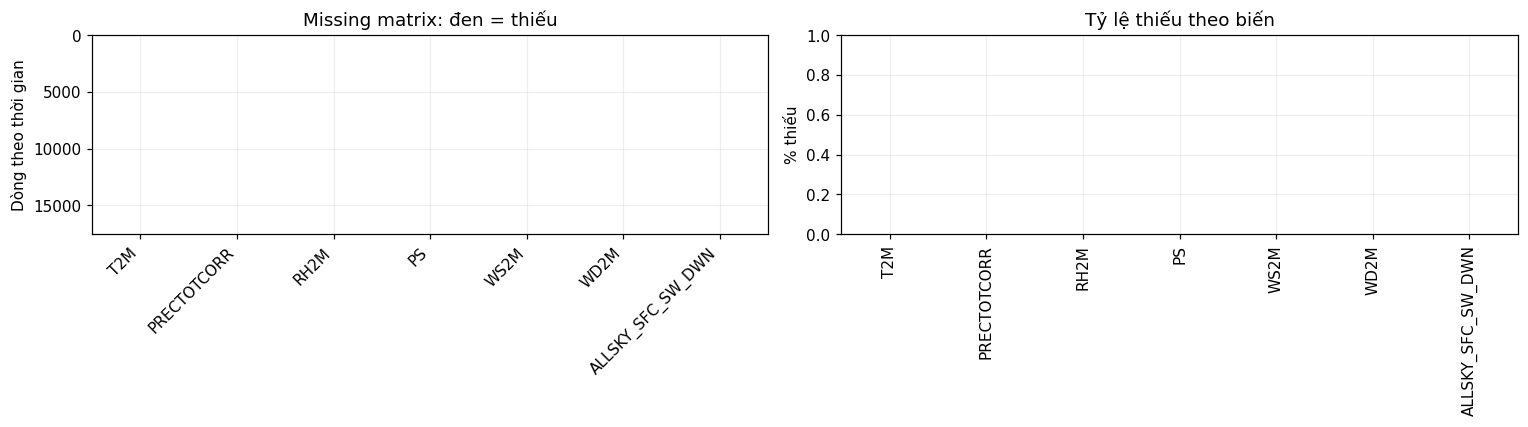

,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN
timestamp,,,,,,,
2023-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN
timestamp,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
missing_mask = baseline[WEATHER_COLS].isna()
fig, axes = plt.subplots(1,2,figsize=(14,4))
axes[0].imshow(missing_mask.to_numpy(), aspect='auto', interpolation='nearest', cmap='Greys', vmin=0, vmax=1)
axes[0].set_xticks(range(len(WEATHER_COLS)), WEATHER_COLS, rotation=45, ha='right')
axes[0].set(title='Missing matrix: đen = thiếu', ylabel='Dòng theo thời gian')
missing_mask.mean().mul(100).plot.bar(ax=axes[1], color='#278b9a')
axes[1].set(title='Tỷ lệ thiếu theo biến', ylabel='% thiếu', ylim=(0, max(1,missing_mask.mean().max()*110)))
plt.tight_layout(); plt.show()
variable_flags = missing_mask.loc[:, missing_mask.nunique() > 1]
if variable_flags.shape[1] >= 2:
    corr = variable_flags.astype(int).corr()
    fig, ax = plt.subplots(figsize=(7,5))
    im = ax.imshow(corr, vmin=-1,vmax=1,cmap='coolwarm')
    ax.set_xticks(range(len(corr)),corr.columns,rotation=45,ha='right')
    ax.set_yticks(range(len(corr)),corr.columns); fig.colorbar(im,ax=ax)
    ax.set_title('Tương quan của cờ thiếu'); plt.tight_layout(); plt.show()
else:
    print('Không đủ cờ thiếu có biến thiên để tính heatmap tương quan.')
missing_month = missing_mask.groupby(baseline.timestamp.dt.strftime('%Y-%m')).mean().mul(100)
missing_hour = missing_mask.groupby(baseline.timestamp.dt.hour).mean().mul(100)
display(missing_month)
display(missing_hour)
print('Tổng ô thiếu sau nhận diện/kiểm tra:', int(missing_mask.sum().sum()))

## 9. W3 — Lập luận cơ chế và chọn cách xử lý
Nếu không có missing, kết luận đúng là **chưa quan sát thấy missing, không cần impute**; không ép nhãn MCAR. Nếu có missing: lỗi tải ngẫu nhiên có thể gợi ý MCAR; thiếu tập trung theo tháng/giờ/nguồn có thể gợi ý MAR; nếu giá trị cực đoan dễ bị mất thì có thể MNAR, cần bằng chứng ngoài bảng dữ liệu.

Chính sách mặc định dưới đây là lựa chọn thực hành, không phải quy định NASA:
- T2M, RH2M, PS, WS2M: có thể giữ giá trị quá khứ cho **cả đoạn thiếu dài tối đa 3 giờ**; không lấy tương lai. Giới hạn 3 giờ là tham số cần thẩm định, không đảm bảo đúng thời tiết thực tế.
- Mưa: không điền 0/trung vị, vì sẽ tự tạo thời tiết khô hoặc nhãn mưa giả.
- Hướng gió: không lấy trung bình/median góc tuyến tính; 359° gần 0°.
- Bức xạ: không kéo giá trị ban ngày qua ban đêm; giữ thiếu để xem xét sau.
- Luôn lưu cờ trước xử lý; không xóa cột chỉ vì thiếu nhiều khi đó là biến mục tiêu quan trọng.

Median toàn bộ, median nhóm và nội suy hai phía chỉ được thử **trên bản sao hồi cứu** ở phần so sánh. Chưa chia train/test không có nghĩa có thể dùng thống kê toàn bộ dữ liệu để đánh giá dự báo sau này.

In [10]:
policy = pd.DataFrame([{
    'column':c, 'n_missing':int(missing_mask[c].sum()),
    'mechanism': 'Không áp dụng: chưa quan sát thiếu' if not missing_mask[c].any() else 'Chưa xác định; cần log nguồn và phân tích tháng/giờ',
    'treatment': 'ffill cho toàn đoạn thiếu ≤3 giờ' if c in CONTINUOUS else 'Giữ NaN + cờ thiếu, điều tra nguồn',
    'reason': 'Chỉ dùng quá khứ; đoạn dài giữ thiếu' if c in CONTINUOUS else 'Không giả định mưa=0, không nội suy góc/bức xạ tùy tiện'
} for c in WEATHER_COLS])
display(policy)

def ffill_short_runs(s, max_gap=3):
    missing = s.isna()
    groups = missing.ne(missing.shift()).cumsum()
    run_size = missing.groupby(groups).transform('sum')
    eligible = missing & (run_size <= max_gap)
    return s.where(~eligible, s.ffill())

for c in WEATHER_COLS:
    work[c + '_was_missing'] = work[c].isna().astype('int8')
    before = work[c].copy()
    after = ffill_short_runs(before, max_gap=3) if c in CONTINUOUS else before.copy()
    filled = before.isna() & after.notna()
    log_changes(filled, c, before, after, 'Đoạn thiếu ≤3 giờ; lấy quan trắc quá khứ gần nhất', 'impute_ffill')
    work[c] = after
    work[c + '_was_imputed'] = filled.astype('int8')
work['is_imputed'] = work[[c+'_was_imputed' for c in WEATHER_COLS]].any(axis=1).astype('int8')
treatment_summary = pd.DataFrame({'missing_before': baseline[WEATHER_COLS].isna().sum(),
    'missing_after': work[WEATHER_COLS].isna().sum(),
    'imputed': [int(work[c+'_was_imputed'].sum()) for c in WEATHER_COLS]}, index=WEATHER_COLS)
display(treatment_summary)

,column,n_missing,mechanism,treatment,reason
0,T2M,0,Không áp dụng: chưa quan sát thiếu,ffill cho toàn đoạn thiếu ≤3 giờ,Chỉ dùng quá khứ; đoạn dài giữ thiếu
1,PRECTOTCORR,0,Không áp dụng: chưa quan sát thiếu,"Giữ NaN + cờ thiếu, điều tra nguồn","Không giả định mưa=0, không nội suy góc/bức xạ..."
2,RH2M,0,Không áp dụng: chưa quan sát thiếu,ffill cho toàn đoạn thiếu ≤3 giờ,Chỉ dùng quá khứ; đoạn dài giữ thiếu
3,PS,0,Không áp dụng: chưa quan sát thiếu,ffill cho toàn đoạn thiếu ≤3 giờ,Chỉ dùng quá khứ; đoạn dài giữ thiếu
4,WS2M,0,Không áp dụng: chưa quan sát thiếu,ffill cho toàn đoạn thiếu ≤3 giờ,Chỉ dùng quá khứ; đoạn dài giữ thiếu
5,WD2M,0,Không áp dụng: chưa quan sát thiếu,"Giữ NaN + cờ thiếu, điều tra nguồn","Không giả định mưa=0, không nội suy góc/bức xạ..."
6,ALLSKY_SFC_SW_DWN,0,Không áp dụng: chưa quan sát thiếu,"Giữ NaN + cờ thiếu, điều tra nguồn","Không giả định mưa=0, không nội suy góc/bức xạ..."


,missing_before,missing_after,imputed
T2M,0,0,0
PRECTOTCORR,0,0,0
RH2M,0,0,0
PS,0,0,0
WS2M,0,0,0
WD2M,0,0,0
ALLSKY_SFC_SW_DWN,0,0,0


## 10. W3 — So sánh chiến lược trên dữ liệu thật (EX3.3)
So sánh T2M: bỏ dòng thiếu, median toàn bộ, median theo (tháng, giờ địa phương), và giữ giá trị quá khứ tối đa 3 giờ. Tất cả làm trên bản sao, không chọn chiến lược chỉ vì trung bình “đẹp”. `n` đếm giá trị có số; `n_rows` là số dòng còn lại; std dùng ddof=1.

Nếu T2M không thiếu, các phương pháp phải cho cùng kết quả. Đây là bằng chứng **không cần xử lý**, không phải lỗi code. Histogram có thể trùng nhau.

T2M không thiếu: các chiến lược không thay đổi dữ liệu. Không có bằng chứng ưu thế từ bảng này.


,n_rows,n,remaining_missing,mean,std
drop,17544.0,17544.0,0.0,24.017949,6.107212
global_median,17544.0,17544.0,0.0,24.017949,6.107212
month_hour_median,17544.0,17544.0,0.0,24.017949,6.107212
past_ffill_3h,17544.0,17544.0,0.0,24.017949,6.107212


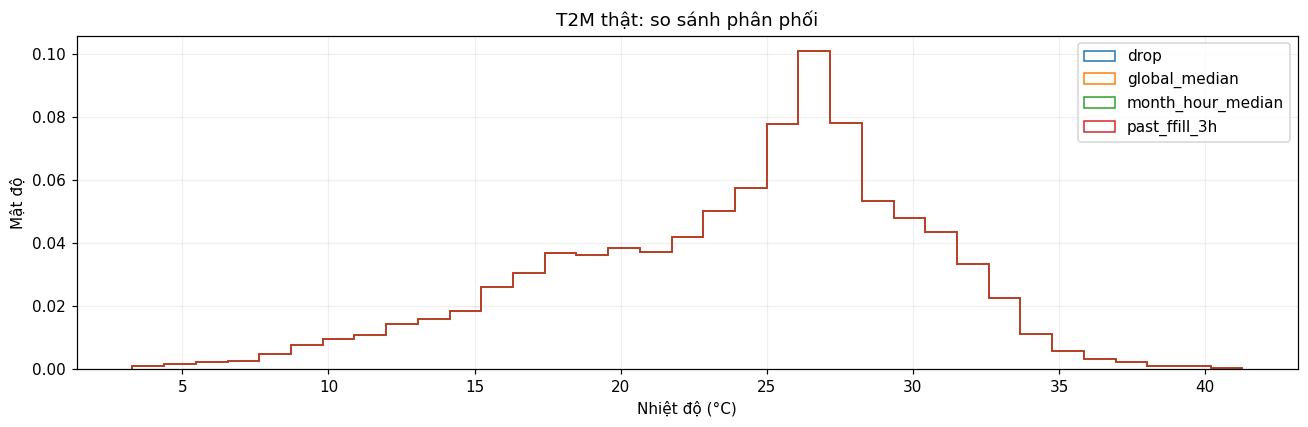

In [11]:
def compare_strategies(s, timestamps):
    group_median = s.groupby([timestamps.dt.month, timestamps.dt.hour]).transform('median')
    return {'drop':s.dropna(), 'global_median':s.fillna(s.median()),
            'month_hour_median':s.fillna(group_median), 'past_ffill_3h':ffill_short_runs(s,3)}
def distribution_stats(series_map):
    return pd.DataFrame({name:{'n_rows':len(s),'n':int(s.notna().sum()),
        'remaining_missing':int(s.isna().sum()),'mean':s.mean(),'std':s.std(ddof=1)}
        for name,s in series_map.items()}).T
real_strategies = compare_strategies(baseline.T2M, baseline.timestamp)
comparison_real = distribution_stats(real_strategies)
display(comparison_real)
fig, ax = plt.subplots()
for name,s in real_strategies.items():
    ax.hist(s.dropna(), bins=35, histtype='step', density=True, label=name)
ax.set(title='T2M thật: so sánh phân phối', xlabel='Nhiệt độ (°C)', ylabel='Mật độ')
ax.legend(); plt.tight_layout(); plt.show()
if baseline.T2M.notna().all():
    print('T2M không thiếu: các chiến lược không thay đổi dữ liệu. Không có bằng chứng ưu thế từ bảng này.')

### 10b. Thử nghiệm minh họa riêng khi dữ liệu không thiếu
Để thấy tác động của imputation theo W3 trang 32: che ngẫu nhiên 5% giá trị T2M **đã biết trên bản sao**, giữ seed cố định; dùng giá trị trước che làm đối chứng. Đây là **thử nghiệm che giá trị**, không chia train/test cho mô hình dự báo và không biến dữ liệu giả thành dữ liệu thật.

Đây là missing nhân tạo kiểu MCAR; kết quả không đại diện cho MAR/MNAR hay khoảng mất dữ liệu dài. Báo cáo MAE chỉ trên ô bị che được điền, kèm tỷ lệ điền để tránh so sánh sai. Nội suy theo thời gian dùng hai phía được thêm như ví dụ hồi cứu; không dùng nó làm đầu vào dự báo thực tế. Có thể tắt bằng `RUN_MASKING_DEMO=False`.

Không dùng kết quả này để khẳng định hiệu quả dự báo t+1 hoặc cơ chế thiếu thật.


,n_rows,n,remaining_missing,mean,std,masked_n,filled_masked_pct,MAE_masked_C
drop,16667.0,16667.0,0.0,24.022853,6.100671,877.0,0.0,NaN
global_median,17544.0,17544.0,0.0,24.086196,5.952634,877.0,100.0,4.930764
month_hour_median,17544.0,17544.0,0.0,24.021345,6.072553,877.0,100.0,2.118649
past_ffill_3h,17544.0,17544.0,0.0,24.017639,6.105724,877.0,100.0,0.730160
time_interpolation_retrospective,17544.0,17544.0,0.0,24.018170,6.103433,877.0,100.0,0.180910


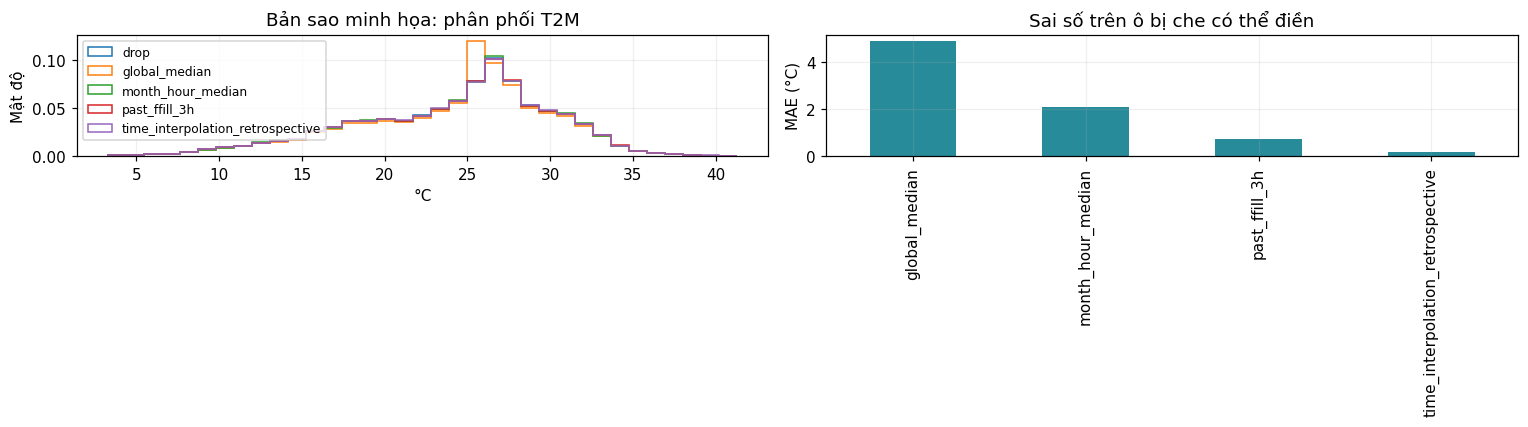

In [12]:
RUN_MASKING_DEMO = True
comparison_demo = pd.DataFrame()
if RUN_MASKING_DEMO:
    truth = baseline.T2M.copy()
    rng = np.random.default_rng(42)
    eligible = truth.index[truth.notna()]
    count = int(len(eligible)*.05)
    if count < 1:
        print('Không đủ quan trắc hợp lệ để chạy minh họa.')
    else:
        hidden = pd.Series(False,index=truth.index)
        hidden.loc[rng.choice(eligible, size=count, replace=False)] = True
        demo = truth.mask(hidden)
        alternatives = compare_strategies(demo, baseline.timestamp)
        timed = pd.Series(demo.to_numpy(), index=pd.DatetimeIndex(baseline.timestamp))
        interp = timed.interpolate(method='time', limit_area='inside')
        alternatives['time_interpolation_retrospective'] = pd.Series(interp.to_numpy(), index=truth.index)
        comparison_demo = distribution_stats(alternatives)
        for name,s in alternatives.items():
            aligned = s.reindex(truth.index)
            scored = hidden & aligned.notna()
            comparison_demo.loc[name,'masked_n'] = int(hidden.sum())
            comparison_demo.loc[name,'filled_masked_pct'] = 100*scored.sum()/hidden.sum()
            comparison_demo.loc[name,'MAE_masked_C'] = (aligned[scored]-truth[scored]).abs().mean()
        display(comparison_demo)
        fig,axes = plt.subplots(1,2,figsize=(14,4))
        for name,s in alternatives.items():
            axes[0].hist(s.dropna(),bins=35,density=True,histtype='step',label=name)
        axes[0].set(title='Bản sao minh họa: phân phối T2M',xlabel='°C',ylabel='Mật độ')
        axes[0].legend(fontsize=8)
        errors = comparison_demo['MAE_masked_C'].dropna()
        errors.plot.bar(ax=axes[1],color='#278b9a')
        axes[1].set(title='Sai số trên ô bị che có thể điền',ylabel='MAE (°C)')
        plt.tight_layout(); plt.show()
        print('Không dùng kết quả này để khẳng định hiệu quả dự báo t+1 hoặc cơ chế thiếu thật.')

## 11. W3 — Chấm 6 chiều chất lượng có bằng chứng (EX3.1)
Điểm dưới đây là rubric thực hành **tạm thời**, không phải thang đo chuẩn của NASA hay điểm giảng viên. Với các tỷ lệ kiểm tra được: 5 nếu đạt 100%; 4 nếu ≥99%; 3 nếu ≥95%; 2 nếu ≥90%; còn lại 1. Completeness tính cả thiếu giờ dự kiến.

**Accuracy:** 3/5 là mức “chưa có đối chứng độc lập”; CSV khớp JSON chỉ chứng minh chuyển đổi trung thực. **Timeliness:** 4/5 tạm cho mục tiêu học lịch sử 2023–2024, 1/5 nếu mục tiêu là dự báo trực tiếp ở hiện tại mà chỉ có snapshot này. Khi thiếu giờ/trùng khóa, notebook dừng ở bước 7 thay vì xuất bảng đạt giả.

In [13]:
def score_rate(r):
    return 5 if r >= 1-1e-12 else 4 if r>=.99 else 3 if r>=.95 else 2 if r>=.90 else 1
expected_cells = len(expected_index)*len(WEATHER_COLS)
completion = baseline[WEATHER_COLS].notna().sum().sum()/expected_cells
valid_rate = 1 - invalid.to_numpy().sum()/(len(raw)*len(WEATHER_COLS))
unique_rate = 1-key_duplicates/len(raw)
quality_scores = pd.DataFrame([
 {'dimension':'Completeness','score_1_5':score_rate(completion),
  'evidence':f'{int(baseline[WEATHER_COLS].notna().sum().sum())}/{expected_cells} ô khí tượng hợp lệ/có dữ liệu; thiếu {len(missing_hours)} giờ'},
 {'dimension':'Accuracy','score_1_5':3,
  'evidence':f'CSV khớp JSON: {json_match}; chưa có trạm độc lập để đo sai số. Điểm tạm, không xác nhận độ chính xác thực địa.'},
 {'dimension':'Consistency','score_1_5':5 if json_match is True else 3,
  'evidence':'Kiểm tra tọa độ, Hanoi, UTC, đơn vị giữa các JSON và CSV; thiếu bằng chứng JSON thì chỉ cho điểm tạm 3.'},
 {'dimension':'Validity','score_1_5':score_rate(valid_rate),
  'evidence':f'{int(invalid.to_numpy().sum())} ô vi phạm miền vật lý cơ bản; không đánh giá ngoại lệ thống kê'},
 {'dimension':'Uniqueness','score_1_5':score_rate(unique_rate),
  'evidence':f'{key_duplicates} khóa trùng; {int(raw.duplicated().sum())} dòng trùng hoàn toàn'},
 {'dimension':'Timeliness','score_1_5':4,
  'evidence':f'Snapshot {source_meta["start"]}–{source_meta["end"]}; phù hợp nghiên cứu lịch sử. Dự báo trực tiếp hiện tại: 1/5, chưa kiểm chứng độ trễ công bố.'}
])
display(quality_scores)

,dimension,score_1_5,evidence
0,Completeness,5,122808/122808 ô khí tượng hợp lệ/có dữ liệu; t...
1,Accuracy,3,CSV khớp JSON: True; chưa có trạm độc lập để đ...
2,Consistency,5,"Kiểm tra tọa độ, Hanoi, UTC, đơn vị giữa các J..."
3,Validity,5,0 ô vi phạm miền vật lý cơ bản; không đánh giá...
4,Uniqueness,5,0 khóa trùng; 0 dòng trùng hoàn toàn
5,Timeliness,4,Snapshot 2023-01-01–2024-12-31; phù hợp nghiên...


## 12. Kiểm tra lại, xuất dữ liệu và nhật ký
Đầu ra W3 là **cleaned**: dữ liệu đã kiểm tra và áp dụng chính sách missing. Còn NaN thì giữ NaN và báo cáo; không xóa mọi dòng bằng `dropna()`.

CSV để trao đổi, Parquet giữ kiểu dữ liệu nếu đã cài `pyarrow`. Hash raw và metadata phải giữ nguyên. Mỗi lần chạy có metadata và báo cáo riêng để truy vết. Các kết quả thử nghiệm nhân tạo không được ghi vào CSV W3.

In [14]:
assert sha256(INPUT) == SOURCE_HASH, 'Raw đã bị thay đổi trong lúc chạy.'
assert sha256(META_PATH) == META_HASH, 'Metadata nguồn đã thay đổi.'
assert len(work) == len(raw)
assert work.timestamp.is_monotonic_increasing and work.timestamp.is_unique
for c in WEATHER_COLS:
    observed = baseline[c].notna()
    assert np.allclose(work.loc[observed,c],baseline.loc[observed,c]), f'Đã đổi quan trắc hợp lệ {c}'
    assert not work[c].isin(fill_values).any()
    assert np.isfinite(work[c].dropna()).all()
final_audit = audit(work)
log_df = pd.DataFrame(change_log, columns=['source_row','column','before','after','reason','action'])
complete_rows = int(work[WEATHER_COLS].notna().all(axis=1).sum())
print('Dòng đầu vào/đầu ra:', len(raw), '/', len(work))
print('Dòng đủ 7 biến sau W3:', complete_rows)
print('Số dòng có ô được điền:', int(work.is_imputed.sum()))
print('Đạt 10.000 dòng đủ biến ở W3:', complete_rows >= 10000)
print('Phạm vi kiểm tra: số dòng và chất lượng của raw → cleaned.')
display(treatment_summary)
display(log_df.head(20))

csv_path = OUTPUT_DIR / 'hanoi_hourly_20230101_20241231_w3.csv'
work.to_csv(csv_path,index=False,encoding='utf-8-sig')
parquet_path = OUTPUT_DIR / 'hanoi_hourly_20230101_20241231_w3.parquet'
parquet_status = 'not_written'
try:
    import pyarrow
    work.to_parquet(parquet_path,index=False)
    parquet_status = 'written'
except ImportError:
    print('Chưa có pyarrow: CSV đã lưu; cài pyarrow nếu cần Parquet.')
reports = {'data_dictionary':dictionary,'audit_raw':raw_audit,'audit_final':final_audit,
    'missing_detection':missing_details,'missing_by_month':missing_month,'missing_by_hour':missing_hour,
    'source_checks':source_checks,'missing_policy':policy,'treatment_summary':treatment_summary,
    'quality_scores':quality_scores,'comparison_real':comparison_real,'change_log':log_df}
if not comparison_demo.empty: reports['comparison_masking_demo_ONLY'] = comparison_demo
for name,table in reports.items(): table.to_csv(REPORT_DIR/f'{name}.csv',encoding='utf-8-sig',index=True)
run_meta = {'run_id':RUN_ID,'source_file':str(INPUT),'source_sha256':SOURCE_HASH,
    'source_metadata_sha256':META_HASH, 'source_generated_at':source_meta.get('generated_at'),
    'source_collector':'Chưa ghi trong metadata nguồn',
    'output_file':str(csv_path),'output_sha256':sha256(csv_path),'raw_rows':len(raw),'output_rows':len(work),
    'complete_weather_rows':complete_rows,'imputed_rows':int(work.is_imputed.sum()),
    'remaining_missing':work[WEATHER_COLS].isna().sum().astype(int).to_dict(),
    'json_csv_match':json_match,'parquet_status':parquet_status,
    'time_zone':'Asia/Ho_Chi_Minh','workflow':'raw_to_cleaned',
    'policy':'Past-only ffill for entire gaps <=3h: T2M/RH2M/PS/WS2M; preserve other missing values',
    'demo_changes_applied_to_output':False,
    'versions':{'python':sys.version.split()[0],'pandas':pd.__version__,'numpy':np.__version__}}
(csv_path.with_suffix('.metadata.json')).write_text(json.dumps(run_meta,ensure_ascii=False,indent=2),encoding='utf-8')
# Báo cáo diễn giải có số liệu thật để sử dụng cho EX3.1/EX3.2.
report_lines = ['# Báo cáo W2–W3: NASA POWER Hà Nội',
    f'Đầu vào: {len(raw):,} dòng, {raw.shape[1]} cột. Phạm vi nguồn: {source_meta["start"]} đến {source_meta["end"]} UTC.',
    f'Thiếu giờ: {len(missing_hours)}; trùng khóa: {key_duplicates}; ô thiếu sau nhận diện: {int(missing_mask.sum().sum())}.',
    f'Đầu ra: {len(work):,} dòng; đủ 7 biến: {complete_rows:,}; dòng có impute: {int(work.is_imputed.sum())}.',
    '## Sáu chiều chất lượng (điểm tạm theo rubric notebook)']
for row in quality_scores.to_dict('records'):
    report_lines.append(f'- {row["dimension"]}: {row["score_1_5"]}/5. {row["evidence"]}')
report_lines += ['## Missing và lựa chọn xử lý']
for row in policy.to_dict('records'):
    report_lines.append(f'- {row["column"]}: thiếu {row["n_missing"]}; {row["mechanism"]}. Chính sách: {row["treatment"]}. {row["reason"]}.')
report_lines += ['## So sánh phương pháp', comparison_real.to_string(),
    'Nếu không có missing, các phương pháp trên dữ liệu thật tương đương. Thử nghiệm che 5% T2M là minh họa độc lập; không dùng làm dữ liệu thật.',
    '## Hạn chế và bước tiếp theo',
    'Chưa có nguồn trạm độc lập xác thực accuracy; chưa kiểm chứng độ trễ công bố hoặc tính sẵn có của biến tại thời điểm dự báo trực tiếp.',
    'Bàn giao cleaned kèm metadata và nhật ký để tiếp tục kiểm tra chất lượng ở W4.',
    'Giữ cờ thiếu/imputed để phân biệt quan trắc gốc và giá trị đã điền; không gọi giá trị điền là quan trắc thực.',
    f'Raw SHA-256: {SOURCE_HASH}']
(REPORT_DIR/'audit_report.md').write_text('\n\n'.join(report_lines),encoding='utf-8')
print('Đã lưu dữ liệu:', csv_path)
print('Đã lưu báo cáo:', REPORT_DIR/'audit_report.md')

Dòng đầu vào/đầu ra: 17544 / 17544
Dòng đủ 7 biến sau W3: 17544
Số dòng có ô được điền: 0
Đạt 10.000 dòng đủ biến ở W3: True
Phạm vi kiểm tra: số dòng và chất lượng của raw → cleaned.
Chưa có pyarrow: CSV đã lưu; cài pyarrow nếu cần Parquet.
Đã lưu dữ liệu: /workspace/scratch/dde99ae4e0a3/project/Weather-Prediction-ML/data/cleaned/w2_w3/20260930T020452005047Z/hanoi_hourly_20230101_20241231_w3.csv
Đã lưu báo cáo: /workspace/scratch/dde99ae4e0a3/project/Weather-Prediction-ML/data/cleaned/w2_w3/20260930T020452005047Z/reports/audit_report.md


,missing_before,missing_after,imputed
T2M,0,0,0
PRECTOTCORR,0,0,0
RH2M,0,0,0
PS,0,0,0
WS2M,0,0,0
WD2M,0,0,0
ALLSKY_SFC_SW_DWN,0,0,0


,source_row,column,before,after,reason,action


## 13. Đọc lại cleaned và đối chiếu raw–cleaned
Đọc lại **đúng CSV vừa xuất**, không lấy một file cleaned khác có thể đã áp dụng chính sách riêng. So sánh theo `source_row` để không nhầm dòng sau khi sắp xếp thời gian.

Bảng đối chiếu cho biết số ô thiếu và số giá trị thay đổi ở từng biến. Các giá trị vốn hợp lệ phải được bảo toàn; chỉ những ô đã được ghi nhận trong nhật ký mới được phép thay đổi. Các chuỗi timestamp UTC và GMT+7 khác nhau về cách viết nhưng phải biểu diễn cùng một thời điểm.

Kiểm tra file raw vẫn giữ nguyên hash. Notebook kết thúc tại cleaned và báo cáo chất lượng. Các báo cáo và thử nghiệm imputation đều nằm trong phạm vi W2–W3; dữ liệu minh họa không được trộn vào cleaned.


In [15]:
cleaned = pd.read_csv(csv_path, encoding='utf-8-sig')
cleaned['timestamp'] = pd.to_datetime(cleaned['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')
assert len(cleaned) == len(raw)
assert cleaned.source_row.is_unique
assert set(cleaned.source_row) == set(range(1, len(raw)+1))
# Khóa truy vết source_row cho phép đối chiếu ngay cả khi đã sắp xếp lại dữ liệu.
left = raw.copy()
left['source_row'] = np.arange(1, len(left)+1)
left = left.set_index('source_row').sort_index()
right = cleaned.set_index('source_row').sort_index()
raw_time = pd.to_datetime(left.timestamp, utc=True)
cleaned_time = pd.to_datetime(right.timestamp, utc=True)
assert raw_time.equals(cleaned_time), 'Làm sạch đã thay đổi thời điểm của bản ghi.'
comparison_rows = []
for c in WEATHER_COLS:
    before = pd.to_numeric(left[c], errors='coerce')
    after = pd.to_numeric(right[c], errors='coerce')
    changed = ~np.isclose(before.to_numpy(dtype=float), after.to_numpy(dtype=float), equal_nan=True)
    comparison_rows.append({'column':c,
        'raw_missing_pandas':int(left[c].isna().sum()),
        'missing_after_detection':int(baseline[c].isna().sum()),
        'cleaned_missing':int(after.isna().sum()),
        'changed_numeric_cells':int(changed.sum()),
        'imputed_cells':int(right[c+'_was_imputed'].sum())})
raw_cleaned_comparison = pd.DataFrame(comparison_rows).set_index('column')
display(raw_cleaned_comparison)
display(cleaned.head())
assert sha256(INPUT) == SOURCE_HASH
assert sha256(csv_path) == run_meta['output_sha256']
raw_cleaned_comparison.to_csv(REPORT_DIR/'raw_cleaned_comparison.csv', encoding='utf-8-sig')
print('Đã kiểm tra raw → cleaned: số dòng, truy vết, thời điểm và hash.')


Đã kiểm tra raw → cleaned: số dòng, truy vết, thời điểm và hash.


,raw_missing_pandas,missing_after_detection,cleaned_missing,changed_numeric_cells,imputed_cells
column,,,,,
T2M,0,0,0,0,0
PRECTOTCORR,0,0,0,0,0
RH2M,0,0,0,0,0
PS,0,0,0,0,0
WS2M,0,0,0,0,0
WD2M,0,0,0,0,0
ALLSKY_SFC_SW_DWN,0,0,0,0,0


,timestamp,city,latitude,longitude,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,...,RH2M_was_imputed,PS_was_missing,PS_was_imputed,WS2M_was_missing,WS2M_was_imputed,WD2M_was_missing,WD2M_was_imputed,ALLSKY_SFC_SW_DWN_was_missing,ALLSKY_SFC_SW_DWN_was_imputed,is_imputed
0,2023-01-01 07:00:00+07:00,Hanoi,21.0285,105.8542,9.75,0.0,83.01,101.62,2.13,17.8,...,0,0,0,0,0,0,0,0,0,0
1,2023-01-01 08:00:00+07:00,Hanoi,21.0285,105.8542,12.01,0.0,71.80,101.66,2.76,30.0,...,0,0,0,0,0,0,0,0,0,0
2,2023-01-01 09:00:00+07:00,Hanoi,21.0285,105.8542,14.32,0.0,64.32,101.66,2.79,40.5,...,0,0,0,0,0,0,0,0,0,0
3,2023-01-01 10:00:00+07:00,Hanoi,21.0285,105.8542,16.32,0.0,60.20,101.60,2.31,41.5,...,0,0,0,0,0,0,0,0,0,0
4,2023-01-01 11:00:00+07:00,Hanoi,21.0285,105.8542,17.81,0.0,58.20,101.48,1.95,39.8,...,0,0,0,0,0,0,0,0,0,0


In [16]:
n_missing = int(missing_mask.sum().sum())
message = ('Không phát hiện giá trị thiếu sau kiểm tra placeholder, sentinel và miền cơ bản; không cần điền dữ liệu.'
           if n_missing == 0 else f'Phát hiện {n_missing} ô thiếu/lỗi; xem missing_policy và change_log để giải thích xử lý.')
display(Markdown(f'**Kết quả W2–W3:** {len(raw):,} dòng gốc; {len(missing_hours)} giờ thiếu; '
                 f'{key_duplicates} khóa trùng. {message} '
                 f'Đầu ra còn {int(work[WEATHER_COLS].isna().sum().sum())} ô thiếu. '
                 '**Hoàn tất raw → cleaned; xem bảng đối chiếu và nhật ký ở trên.**'))

**Kết quả W2–W3:** 17,544 dòng gốc; 0 giờ thiếu; 0 khóa trùng. Không phát hiện giá trị thiếu sau kiểm tra placeholder, sentinel và miền cơ bản; không cần điền dữ liệu. Đầu ra còn 0 ô thiếu. **Hoàn tất raw → cleaned; xem bảng đối chiếu và nhật ký ở trên.**